In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import re

import matplotlib
matplotlib.use('TkAgg')

from ipywidgets import Button, HBox
import ipywidgets as widgets
import matplotlib.pyplot as plt

from matplotlib import patches
from matplotlib import cm
from matplotlib.colors import ListedColormap
from matplotlib import animation
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator, ScalarFormatter, FuncFormatter
from matplotlib.colors import ListedColormap

import matplotlib.gridspec as gridspec

from mpl_toolkits.mplot3d.art3d import Line3DCollection

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [2]:
%matplotlib inline

# Filtering the data

In [4]:
# Loading the CSV
df = pd.read_csv('data/data_suicide/suicide.csv', encoding='utf-8')

# FILTERING
# Drop rows with missing or unreliable data
df = df[df['FLAG'].isna()]  # Only keep rows where FLAG is NaN and not ...
df = df[df['YEAR'] >= 1980] # Filter out years before 1980

print(df.head())

                                                UNIT STUB_NAME   STUB_LABEL  \
3  Deaths per 100,000 resident population, age-ad...     Total  All persons   
4  Deaths per 100,000 resident population, age-ad...     Total  All persons   
5  Deaths per 100,000 resident population, age-ad...     Total  All persons   
6  Deaths per 100,000 resident population, age-ad...     Total  All persons   
7  Deaths per 100,000 resident population, age-ad...     Total  All persons   

   YEAR  ESTIMATE FLAG  
3  1980      12.2  NaN  
4  1981      12.3  NaN  
5  1982      12.5  NaN  
6  1983      12.4  NaN  
7  1984      12.6  NaN  


# Ex2: Visualisation of Crude and age-adjusted results for sex only


dual axis female and male
male one saide female other

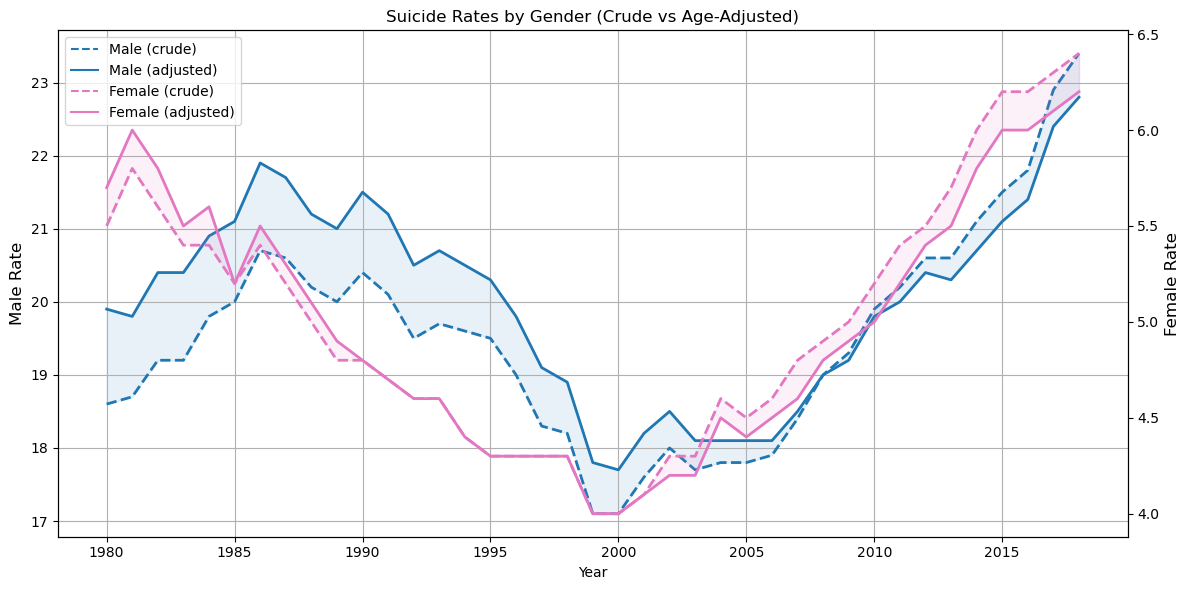

In [5]:
# Filter by STUB_NAME for sex only 
df_sex = df[df['STUB_NAME'] == 'Sex']

# Split crude and age-adjusted using UNIT
df_crude = df_sex[df_sex['UNIT'].str.contains('crude', case=False)]
df_adjusted = df_sex[df_sex['UNIT'].str.contains('age-adjusted', case=False)]

# Pivot tables for plotting
crude_pivot = df_crude.pivot_table(index='YEAR', columns='STUB_LABEL', values='ESTIMATE')
adjusted_pivot = df_adjusted.pivot_table(index='YEAR', columns='STUB_LABEL', values='ESTIMATE')

# Set up figure and dual axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Get male and female data
crude_male = crude_pivot['Male']
crude_female = crude_pivot['Female']
adj_male = adjusted_pivot['Male']
adj_female = adjusted_pivot['Female']

# Color mapping
color_male = '#1f77b4'     # Blue
color_female = '#e377c2'   # Pink

# === Male Plot on Primary Axis ===
ax1.set_ylabel('Male Rate', size = 12)
ax1.plot(crude_male.index, crude_male, linestyle='--', linewidth=2, color=color_male, label='Male (crude)')
ax1.plot(adj_male.index, adj_male, linestyle='-', linewidth=2, color=color_male, label='Male (adjusted)')
ax1.tick_params(axis='y')

# === Female Plot on Secondary Axis ===
ax2 = ax1.twinx()
ax2.set_ylabel('Female Rate', size = 12)
ax2.plot(crude_female.index, crude_female, linestyle='--', linewidth=2, color=color_female, label='Female (crude)')
ax2.plot(adj_female.index, adj_female, linestyle='-', linewidth=2, color=color_female, label='Female (adjusted)')
ax2.tick_params(axis='y')

# === Title, axis, legend ===
plt.title('Suicide Rates by Gender (Crude vs Age-Adjusted)')
ax1.set_xlabel('Year')
ax1.grid(True)

# Custom legend combining both axes
legend_lines = [
    Line2D([0], [0], color=color_male, linestyle='--', label='Male (crude)'),
    Line2D([0], [0], color=color_male, linestyle='-', label='Male (adjusted)'),
    Line2D([0], [0], color=color_female, linestyle='--', label='Female (crude)'),
    Line2D([0], [0], color=color_female, linestyle='-', label='Female (adjusted)')
]

# Between crude and adjusted for male
ax1.fill_between(crude_male.index, crude_male, adj_male, color='#1f77b4', alpha=0.1)

# Between crude and adjusted for female
ax2.fill_between(crude_female.index, crude_female, adj_female, color='#e377c2', alpha=0.1)

ax1.legend(handles=legend_lines, loc='upper left')

plt.tight_layout()
plt.show()


# Ex3: 
merge adjuted rate andraet to one plot and splıt by age

crude age adjusted --
gender division to two plots
split by age


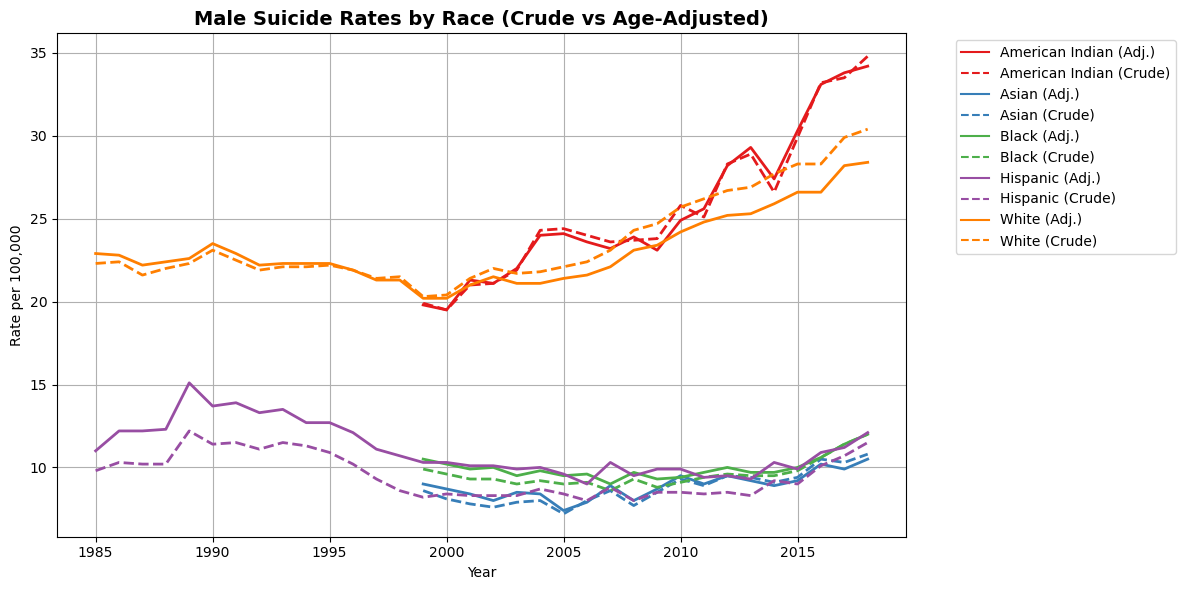

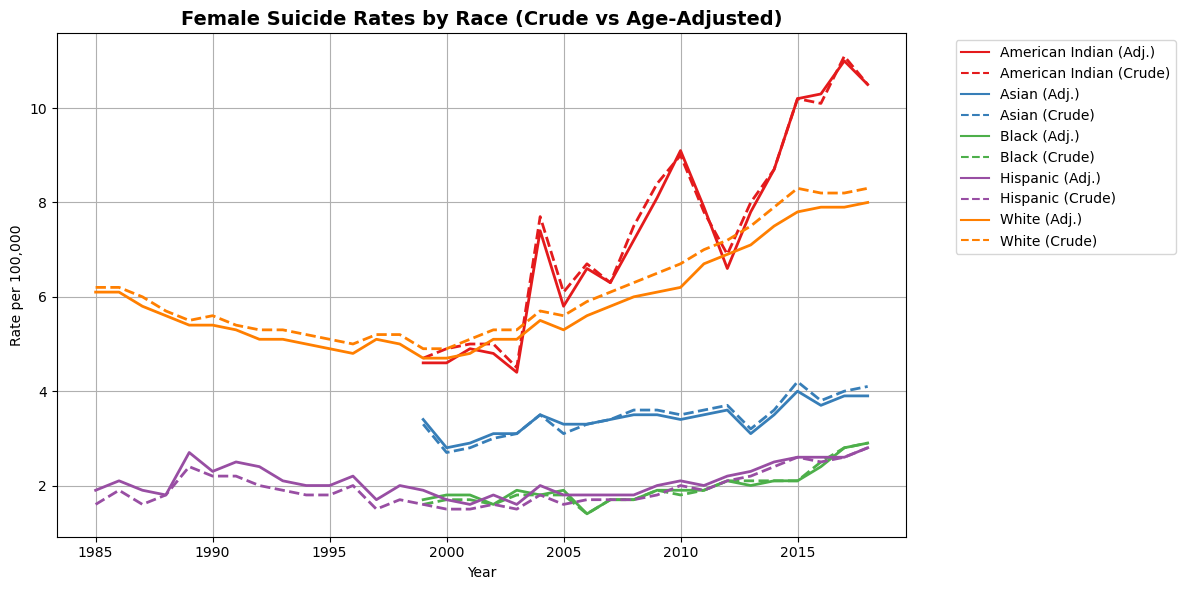

In [6]:
# === Load and clean data ===
df_gender_race = df[df['STUB_NAME'] == 'Sex and race and Hispanic origin'].copy()

# Extract Gender and Race
df_gender_race[['Gender', 'Race']] = df_gender_race['STUB_LABEL'].str.extract(r'^(Male|Female):\s*([^:]+)')

# Simplify Race name until or
df_gender_race['Race'] = df_gender_race['Race'].str.split(' or').str[0].str.strip()

# Identify Crude or Age-Adjusted
df_gender_race['RateType'] = df_gender_race['UNIT'].str.extract(r'(crude|age-adjusted)', flags=re.IGNORECASE)[0].str.title()

# Drop missing estimates
df_gender_race = df_gender_race[df_gender_race['ESTIMATE'].notna()]

# === Plotting loop: One plot for Male, one for Female ===
for gender in ['Male', 'Female']:
    df_sex = df_gender_race[df_gender_race['Gender'] == gender].copy()

    plt.figure(figsize=(12, 6))
    plt.title(f'{gender} Suicide Rates by Race (Crude vs Age-Adjusted)', fontsize=14, weight='bold')
    plt.xlabel('Year')
    plt.ylabel('Rate per 100,000')
    plt.grid(True)

    # Setup color palette
    races = sorted(df_sex['Race'].unique())
    palette = sns.color_palette('Set1', n_colors=len(races))
    color_map = dict(zip(races, palette))

    # Plot each race's lines
    for race in races:
        for rate_type, style in [('Age-Adjusted', '-'), ('Crude', '--')]:
            data = df_sex[(df_sex['Race'] == race) & (df_sex['RateType'] == rate_type)].sort_values('YEAR')
            if not data.empty:
                plt.plot(data['YEAR'], data['ESTIMATE'],
                         label=f'{race} ({rate_type})',
                         color=color_map[race],
                         linestyle=style,
                         linewidth=2)

    # Custom legend with one entry per race + line style hint
    legend_lines = []
    for race in races:
        legend_lines.append(Line2D([0], [0], color=color_map[race], linestyle='-', label=f'{race} (Adj.)'))
        legend_lines.append(Line2D([0], [0], color=color_map[race], linestyle='--', label=f'{race} (Crude)'))

    plt.legend(handles=legend_lines, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


# Races by aggregating the age

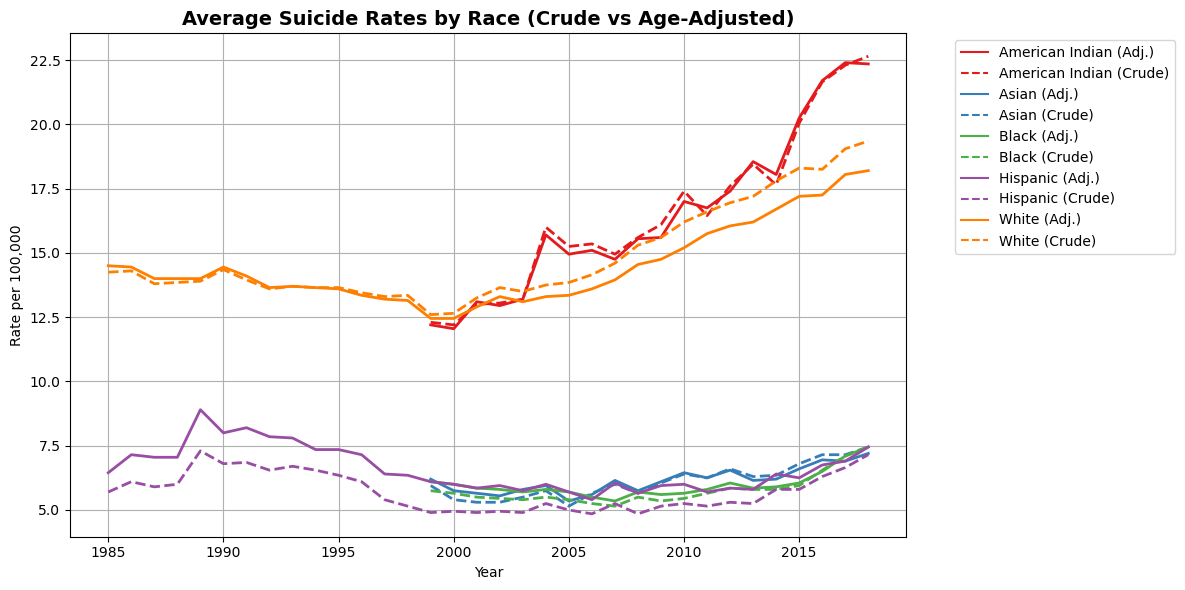

In [7]:
# === COMBINED SEXES PLOT (Assume 50/50 weighting) ===
df_combo = df_gender_race.copy()

# Group and average across genders per year, race, and rate type
df_avg = df_combo.groupby(['YEAR', 'Race', 'RateType'])['ESTIMATE'].mean().reset_index()

# === Begin plot ===
plt.figure(figsize=(12, 6))
plt.title('Average Suicide Rates by Race (Crude vs Age-Adjusted)', fontsize=14, weight='bold')
plt.xlabel('Year')
plt.ylabel('Rate per 100,000')
plt.grid(True)

# Use vibrant color palette
races = sorted(df_avg['Race'].unique())
palette = sns.color_palette('Set1', n_colors=len(races))
color_map = dict(zip(races, palette))

# Plot each race's lines
for race in races:
    for rate_type, style in [('Age-Adjusted', '-'), ('Crude', '--')]:
        data = df_avg[(df_avg['Race'] == race) & (df_avg['RateType'] == rate_type)].sort_values('YEAR')
        if not data.empty:
            plt.plot(data['YEAR'], data['ESTIMATE'],
                     label=f'{race} ({rate_type})',
                     color=color_map[race],
                     linestyle=style,
                     linewidth=2)

# Custom legend
legend_lines = []
for race in races:
    legend_lines.append(Line2D([0], [0], color=color_map[race], linestyle='-', label=f'{race} (Adj.)'))
    legend_lines.append(Line2D([0], [0], color=color_map[race], linestyle='--', label=f'{race} (Crude)'))

plt.legend(handles=legend_lines, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# Ex4

bins of larger age
color for female and male

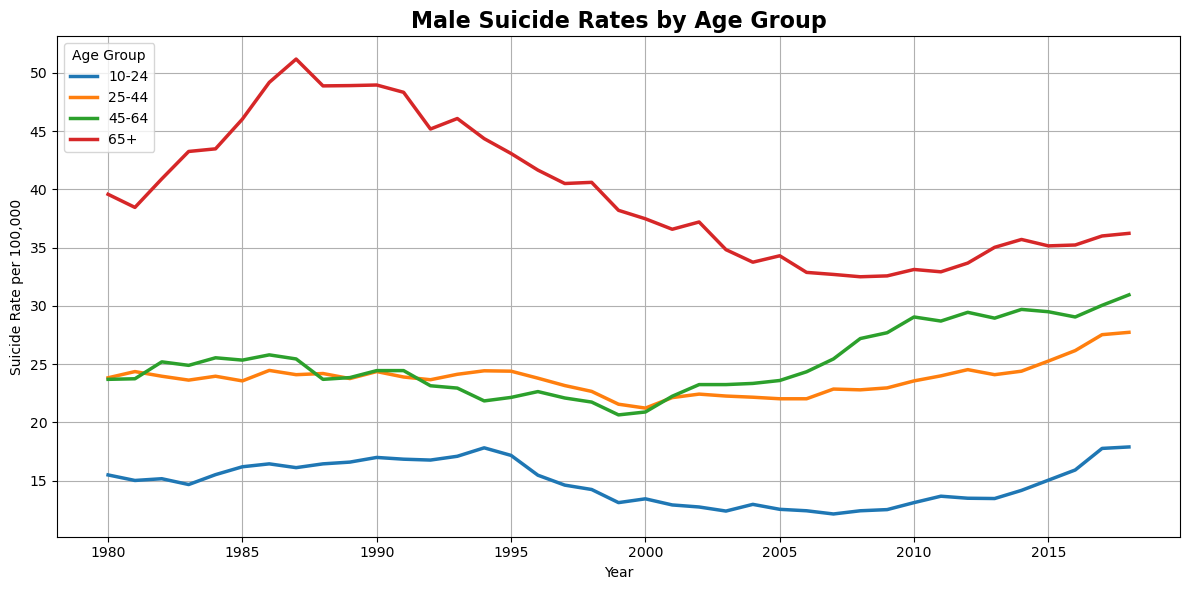

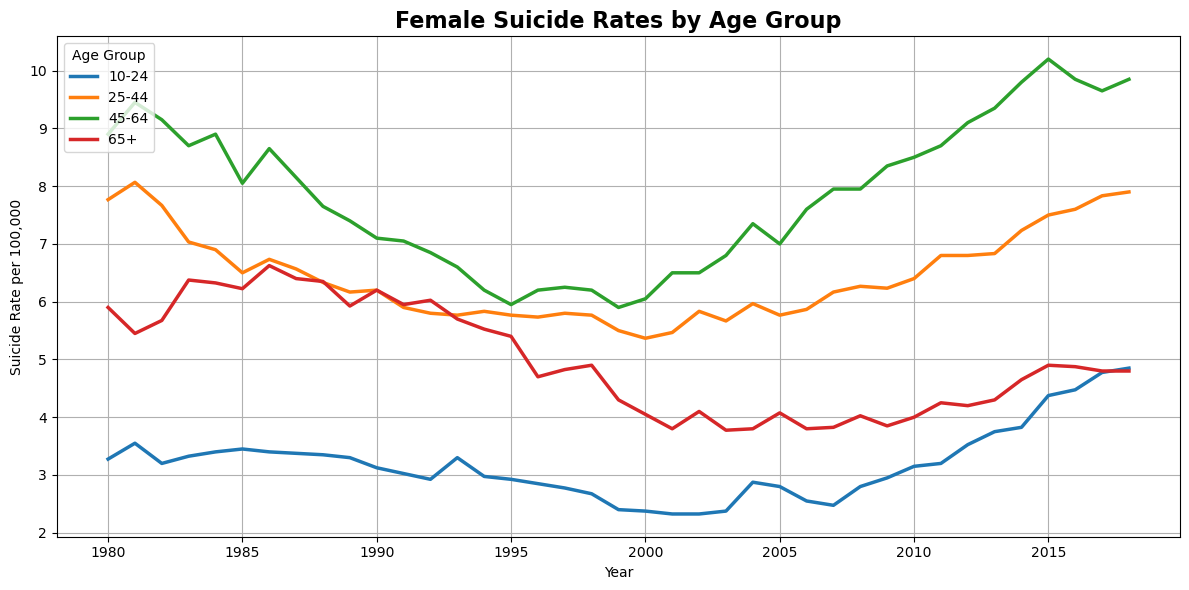

In [8]:
# === 1. Filter relevant rows ===
df_gender_age = df[(df['STUB_NAME'] == 'Sex and age') & df['UNIT'].str.contains('crude')].copy()

# === 2. Parse Gender and Age ===
df_gender_age[['Gender', 'AgeGroupRaw']] = df_gender_age['STUB_LABEL'].str.extract(r'^(Male|Female):\s*(.*)')

# === 3. Clean overlapping bins
age_bin_map = {
    '10-14 years': '10-24',
    '15-19 years': '10-24',
    '15-24 years': '10-24',
    '20-24 years': '10-24',
    '25-34 years': '25-44',
    '25-44 years': '25-44',
    '35-44 years': '25-44',
    '45-54 years': '45-64',
    '55-64 years': '45-64',
    '65-74 years': '65+',
    '65 years and over': '65+',
    '75-84 years': '65+',
    '85 years and over': '65+'
}
df_gender_age['AgeBin'] = df_gender_age['AgeGroupRaw'].map(age_bin_map)
df_gender_age = df_gender_age.dropna(subset=['AgeBin'])

# === 4. Pivot data ===
pivot = df_gender_age.pivot_table(index='YEAR', columns=['Gender', 'AgeBin'], values='ESTIMATE')

# === 5. Define vibrant colors by age bin ===
age_colors = {
    '10-24': '#1f77b4',  # blue
    '25-44': '#ff7f0e',  # orange
    '45-64': '#2ca02c',  # green
    '65+':   '#d62728'   # red
}

# === 6. Plot Male and Female separately ===
for gender, linestyle in [('Male', '-'), ('Female', '-')]:
    plt.figure(figsize=(12, 6))
    plt.title(f'{gender} Suicide Rates by Age Group', fontsize=16, weight='bold')
    
    for age_bin in sorted(age_colors.keys()):
        try:
            plt.plot(pivot.index, pivot[gender, age_bin],
                     label=age_bin,
                     color=age_colors[age_bin],
                     linestyle=linestyle,
                     linewidth=2.5)
        except KeyError:
            continue  # Skip missing combinations

    plt.xlabel('Year')
    plt.ylabel('Suicide Rate per 100,000')
    plt.grid(True)
    plt.legend(title='Age Group', loc='upper left')
    plt.tight_layout()
    plt.show()


# Ages by aggregating data

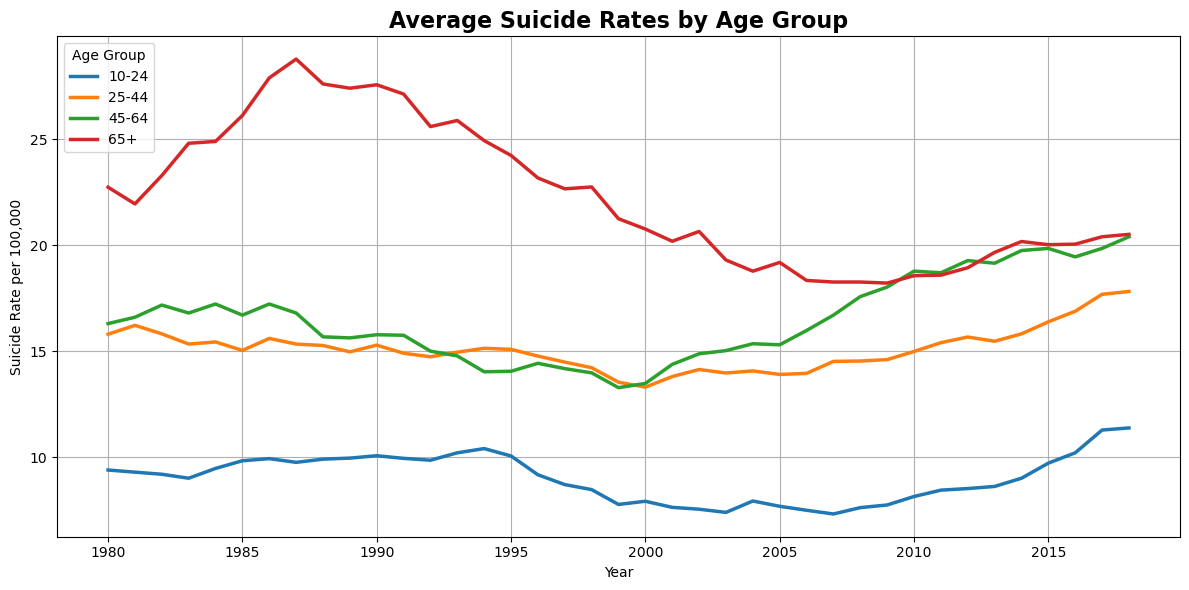

In [9]:
# === 1. Filter relevant rows ===
df_gender_age = df[(df['STUB_NAME'] == 'Sex and age') & df['UNIT'].str.contains('crude')].copy()

# === 2. Parse Gender and Age ===
df_gender_age[['Gender', 'AgeGroupRaw']] = df_gender_age['STUB_LABEL'].str.extract(r'^(Male|Female):\s*(.*)')

# === 3. Clean overlapping bins
age_bin_map = {
    '10-14 years': '10-24',
    '15-19 years': '10-24',
    '15-24 years': '10-24',
    '20-24 years': '10-24',
    '25-34 years': '25-44',
    '25-44 years': '25-44',
    '35-44 years': '25-44',
    '45-54 years': '45-64',
    '55-64 years': '45-64',
    '65-74 years': '65+',
    '65 years and over': '65+',
    '75-84 years': '65+',
    '85 years and over': '65+'
}
df_gender_age['AgeBin'] = df_gender_age['AgeGroupRaw'].map(age_bin_map)
df_gender_age = df_gender_age.dropna(subset=['AgeBin', 'ESTIMATE'])

# === 4. Average across genders ===
df_avg = df_gender_age.groupby(['YEAR', 'AgeBin'])['ESTIMATE'].mean().reset_index()

# === 5. Pivot for plotting ===
pivot_avg = df_avg.pivot(index='YEAR', columns='AgeBin', values='ESTIMATE')

# === 6. Define vibrant colors by age bin ===
age_colors = {
    '10-24': '#1f77b4',  # blue
    '25-44': '#ff7f0e',  # orange
    '45-64': '#2ca02c',  # green
    '65+':   '#d62728'   # red
}

# === 7. Plot combined line chart ===
plt.figure(figsize=(12, 6))
plt.title('Average Suicide Rates by Age Group', fontsize=16, weight='bold')

for age_bin in sorted(age_colors.keys()):
    if age_bin in pivot_avg.columns:
        plt.plot(pivot_avg.index, pivot_avg[age_bin],
                 label=age_bin,
                 color=age_colors[age_bin],
                 linewidth=2.5)

plt.xlabel('Year')
plt.ylabel('Suicide Rate per 100,000')
plt.grid(True)
plt.legend(title='Age Group', loc='upper left')
plt.tight_layout()
plt.show()


# Ex5

split by age
interpolation by marking

# indicator lines on the x axis 

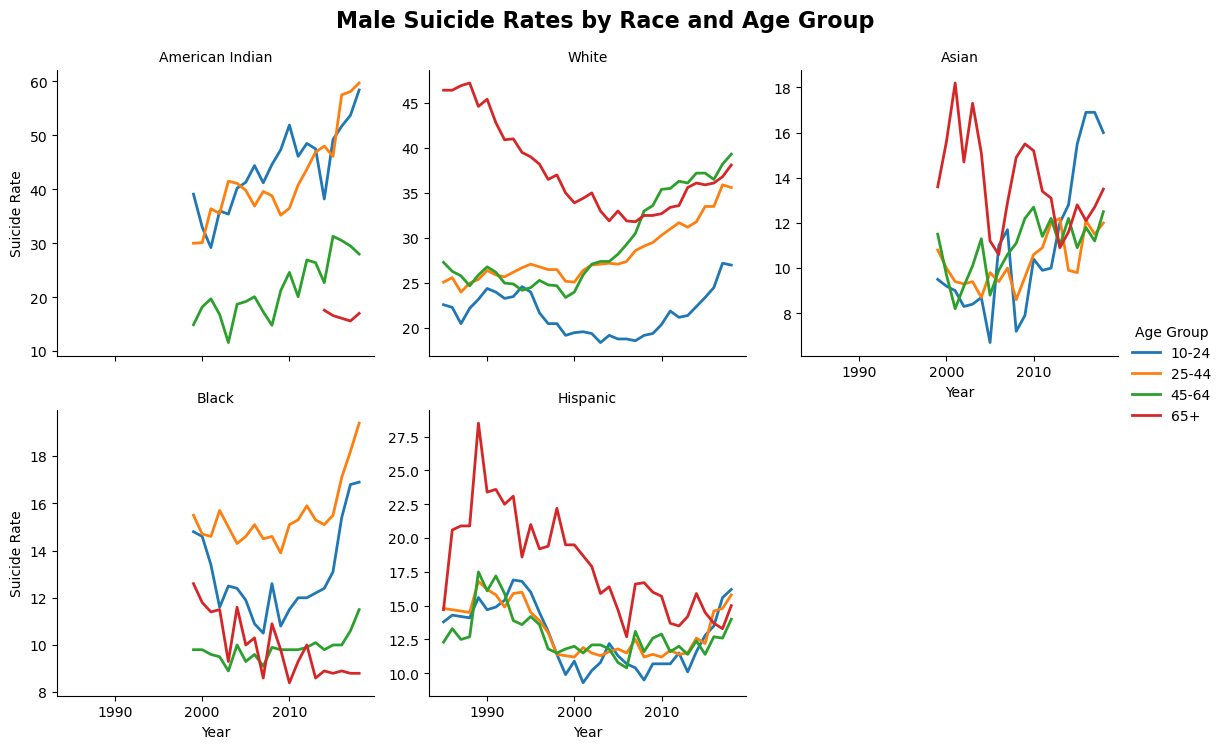

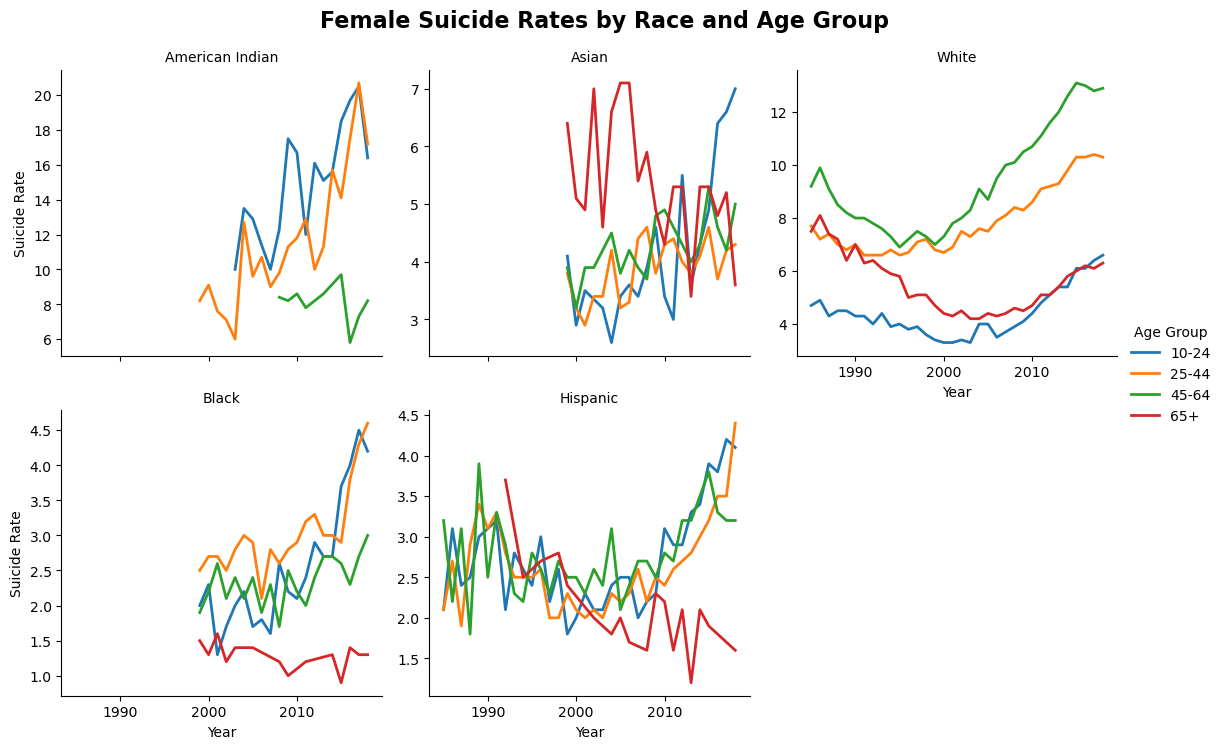

In [10]:
# === 1. Filter dataset ===
df_all = df[(df['STUB_NAME'] == 'Sex, age and race and Hispanic origin') & df['UNIT'].str.contains('crude')].copy()

# === 2. Parse properly: fix "or" race names ===
df_all[['Gender', 'Race', 'AgeGroupRaw']] = df_all['STUB_LABEL'].str.extract(r'^(Male|Female):\s*(.+?)\s*:\s*(.+)$')

# Simplify Race name until or
df_all['Race'] = df_all['Race'].str.split(' or').str[0].str.strip()

# === 3. Clean up overlapping age groups with bins ===
age_bin_map = {
    '10-14 years': '10-24',
    '15-19 years': '10-24',
    '15-24 years': '10-24',
    '20-24 years': '10-24',
    '25-34 years': '25-44',
    '25-44 years': '25-44',
    '35-44 years': '25-44',
    '45-64 years': '45-64',
    '65-74 years': '65+',
    '65 years and over': '65+',
    '75-84 years': '65+',
    '85 years and over': '65+'
}

df_all['AgeBin'] = df_all['AgeGroupRaw'].map(age_bin_map)
df_all = df_all.dropna(subset=['AgeBin', 'ESTIMATE'])

# === 4. Function to plot per gender ===
def plot_gender_facets(gender):
    subset = df_all[df_all['Gender'] == gender].copy()
    
    # Set color palette for age bins
    age_colors = {
        '10-24': '#1f77b4',
        '25-44': '#ff7f0e',
        '45-64': '#2ca02c',
        '65+': '#d62728'
    }
    
    # Set order for plots
    race_order = subset['Race'].dropna().unique()
    
    # Initialize FacetGrid
    g = sns.FacetGrid(subset, col="Race", col_wrap=3, height=3.8, sharey=False)
    
    # Plot each subplot
    g.map_dataframe(sns.lineplot, x='YEAR', y='ESTIMATE', hue='AgeBin', palette=age_colors, linewidth=2)
    
    g.set_titles("{col_name}")
    g.set_axis_labels("Year", "Suicide Rate")
    g.add_legend(title='Age Group')
    g.fig.subplots_adjust(top=0.9)
    g.fig.suptitle(f"{gender} Suicide Rates by Race and Age Group", fontsize=16, weight='bold')

    plt.show()

# === 5. Plot separately for Male and Female ===
plot_gender_facets('Male')
plot_gender_facets('Female')


# numbers written in the heatmap, and invert for contrast

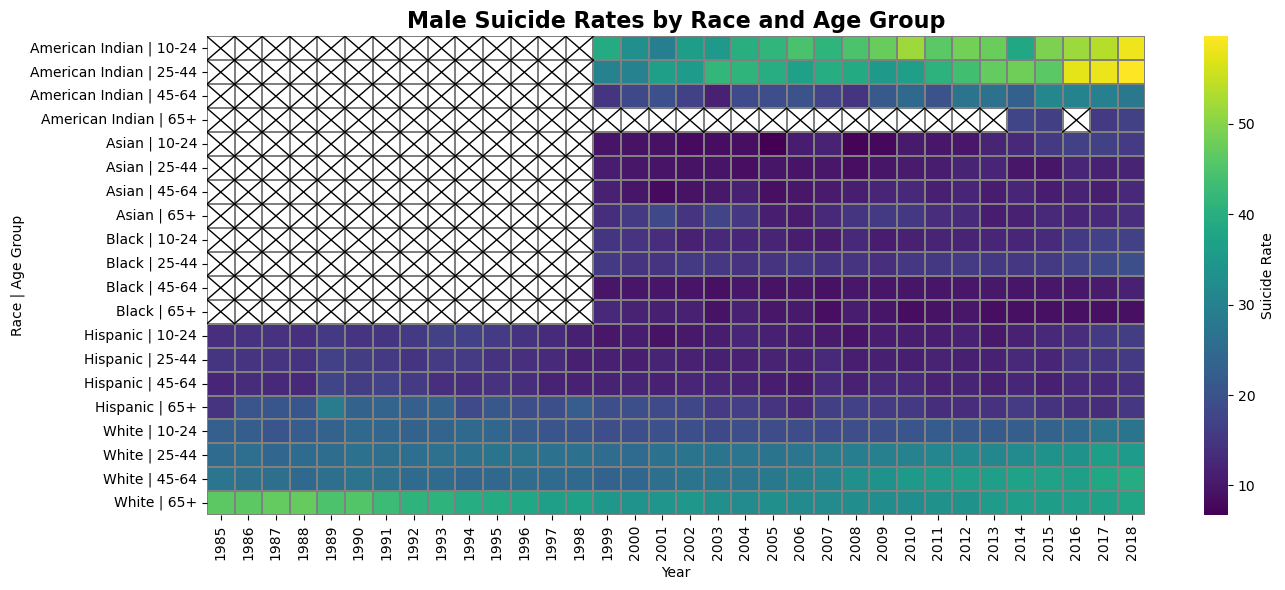

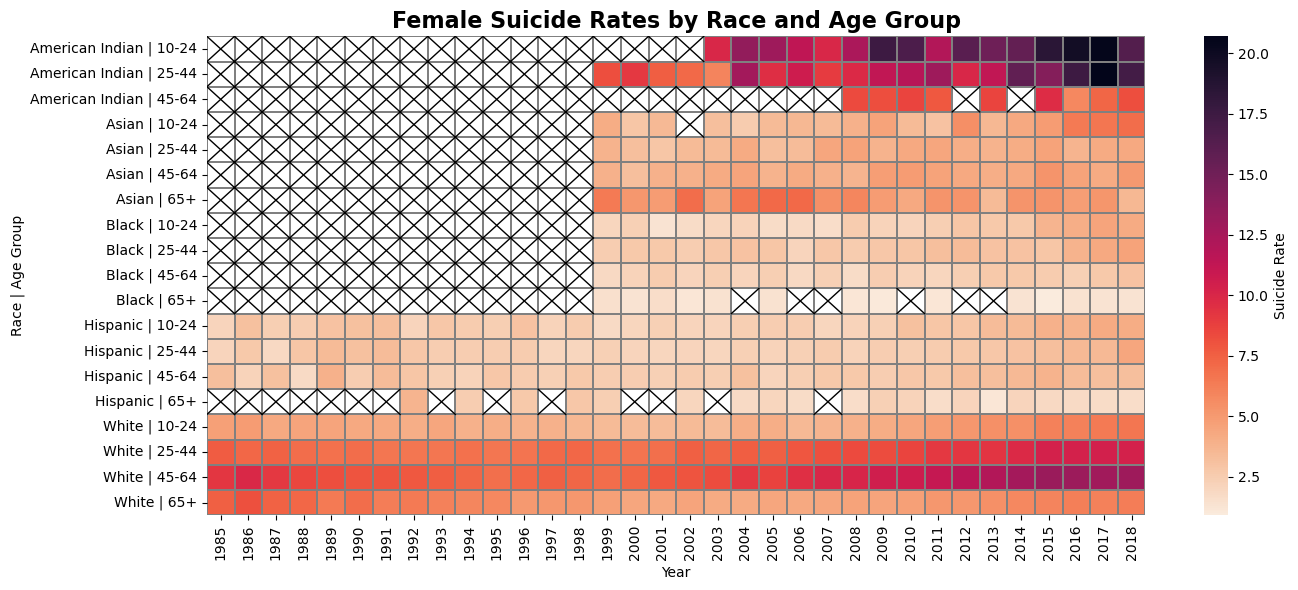

In [11]:
# === 1. Filter dataset ===
df_all = df[(df['STUB_NAME'] == 'Sex, age and race and Hispanic origin') & df['UNIT'].str.contains('crude')].copy()

# === 2. Parse labels correctly (keep full race names) ===
df_all[['Gender', 'Race', 'AgeGroupRaw']] = df_all['STUB_LABEL'].str.extract(r'^(Male|Female):\s*(.+?)\s*:\s*(.+)$')
df_all['Race'] = df_all['Race'].str.split(' or').str[0].str.strip()

# === 3. Clean up age groups
age_bin_map = {
    '10-14 years': '10-24',
    '15-19 years': '10-24',
    '15-24 years': '10-24',
    '20-24 years': '10-24',
    '25-34 years': '25-44',
    '25-44 years': '25-44',
    '35-44 years': '25-44',
    '45-64 years': '45-64',
    '65-74 years': '65+',
    '65 years and over': '65+',
    '75-84 years': '65+',
    '85 years and over': '65+'
}
df_all['AgeBin'] = df_all['AgeGroupRaw'].map(age_bin_map)
df_all = df_all.dropna(subset=['AgeBin', 'ESTIMATE'])

# === 4. Combine Race and AgeBin for row labels
df_all['Group'] = df_all['Race'] + ' | ' + df_all['AgeBin']

# === 5. Function to plot heatmap with missing-data cross overlay
def plot_heatmap(gender):
    if gender == 'Male':
        cmap = 'viridis'
    else:
        cmap = 'rocket_r'
        
    df_gender = df_all[df_all['Gender'] == gender].copy()
    
    # Pivot: rows = Group, columns = YEAR
    heatmap_data = df_gender.pivot_table(index='Group', columns='YEAR', values='ESTIMATE')
    heatmap_data = heatmap_data.sort_index()

    # Create mask for missing data
    mask = heatmap_data.isna()
    
    fig, ax = plt.subplots(figsize=(14, max(6, 0.3 * len(heatmap_data))))
    
    # Plot the heatmap
    sns.heatmap(
        heatmap_data,
        cmap=cmap,
        linewidths=0.3,
        linecolor='gray',
        annot=False,
        cbar_kws={'label': 'Suicide Rate'},
        mask=mask,
        ax=ax
    )
    
    from matplotlib.lines import Line2D

    # Overlay X's on missing cells
    for y, row in enumerate(heatmap_data.index):
        for x, col in enumerate(heatmap_data.columns):
            if pd.isna(heatmap_data.loc[row, col]):
                # Get cell center coordinates
                x0, x1 = x, x + 1
                y0, y1 = y, y + 1

                # Diagonal lines
                ax.add_line(Line2D([x0, x1], [y0, y1], color='black', linewidth=1))
                ax.add_line(Line2D([x0, x1], [y1, y0], color='black', linewidth=1))



    ax.set_title(f'{gender} Suicide Rates by Race and Age Group', fontsize=16, weight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Race | Age Group')
    plt.tight_layout()
    plt.show()

# === 6. Plot both
plot_heatmap('Male')
plot_heatmap('Female')


# Problem 2: Tourism Accommodation Statistics of Kärnten


## 1. Import the Main Data

Load the primary dataset `tourism.csv` and the auxiliary mapping `origin_category.csv`.

**Goal:** Understand the structure before analysis.

---
 It contains the following columns:

Tourismusjahr, dtype: int64 Year of the observation

Unterkunft, dtype: object Type of accommodation. Includes hotels of different comfort levels, vacation homes, campign sites, et cetera.

Herkunft, dtype: object Origin of the travellers. Split into states in Austria, Germany, countries in Europe and elsewhere in the world. Some countries are aggregated (e.g. "Übriges Asien").

---


The file origin_category.csv contains a categorization of all origin values into four groups: Austria, Germany, Europe, International (as in "rest of the world"). This categorization may be useful for presenting the data.

 Ankünfte, dtype: int64 Amount of arrivals in given year, in given type of accommodation, by travellers of given origin.

 Übernachtungen, dtype: int64 Amount of nights spent in given year, in given type of accommodation, by travellers of given origin.


In [4]:
df_tourism= pd.read_csv('data/data_tourism/tourism.csv')
df_origin_category =pd.read_csv('data/data_tourism/origin_category.csv')
df_tourism

,Tourismusjahr,Unterkunft,Herkunft,Ankünfte,Übernachtungen
0,2008,Bewirtschaftete Schutzhütten,Australien,2,2
1,2008,Bewirtschaftete Schutzhütten,Baden Württemberg,440,632
2,2008,Bewirtschaftete Schutzhütten,Bayern,836,1608
3,2008,Bewirtschaftete Schutzhütten,Belgien,78,110
4,2008,Bewirtschaftete Schutzhütten,Berlin,570,657
...,...,...,...,...,...
11989,2021,Unterkunft auf Bauernhof,ehem. Jugoslawien,130,1287
11990,2021,Unterkunft auf Bauernhof,Übriges Afrika,14,60
11991,2021,Unterkunft auf Bauernhof,Übriges Asien,15,32
11992,2021,Unterkunft auf Bauernhof,Übriges Ausland,23,256


## 2. Total Nights by Tourist Origin

Visualize the total number of nights spent by tourists from different origins. The auxiliary
file origin_category.csv may be useful here. (1-2 charts)

**Hint:** Use `origin_category.csv` to group origins into meaningful categories (e.g., Domestic, Germany, Europe, Other International).

**Deliverables:**
- Bar chart: Total nights per origin category.
- Optional: Pie chart for proportional comparison.

**Critical thinking:**
- Which origin group dominates?
- Do the results match expectations for a border region like Kärnten?

---

# Put the legend of pie chart outside

In [5]:
#add the origin category to the main dataset
origin_col = []
for country in df_tourism['Herkunft']:
    origin = df_origin_category[df_origin_category['Herkunft'] == country]['Herkunft Kategorie'].tolist()[0]
    origin_col.append(origin)

df_tourism.insert(len(df_tourism.columns)-1, 'Herkunft Kategorie', origin_col)

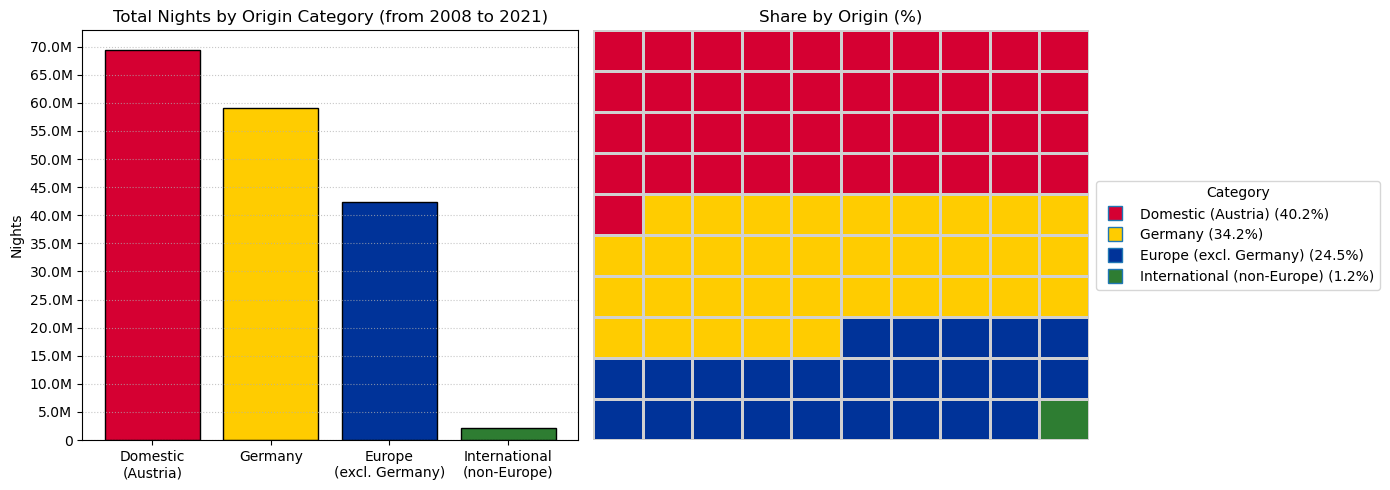

In [5]:
group_a = df_tourism.groupby('Herkunft Kategorie').agg({'Übernachtungen':'sum'})
color_map = {
    "Germany": "#FFCC00",
    "Domestic (Austria)": "#D50032",
    "Europe (excl. Germany)": "#003399",
    "International (non-Europe)": "#2E7D32",
}

cat_map = {
    "AT": "Domestic (Austria)",
    "DE": "Germany",
    "EUR": "Europe (excl. Germany)",
    "INT": "International (non-Europe)"
}
group_a = group_a.rename(index=cat_map)

def human_format(x, pos):
    if x >= 1e6: return f'{x/1e6:.1f}M'
    if x >= 1e3: return f'{x/1e3:.0f}k'
    return f'{x:.0f}'

fig, axs = plt.subplots(1, 2, figsize=(14,5))

axs[0].cla()
axs[0].bar(group_a.index, group_a['Übernachtungen'],
           color=[color_map[l] for l in group_a.index],
           edgecolor='black')
axs[0].set_title("Total Nights by Origin Category (from 2008 to 2021)")
axs[0].set_ylabel("Nights")
axs[0].set_xticks(range(len(group_a)))

axs[0].set_xticklabels([
    'Domestic\n(Austria)',
    'Germany',
    'Europe\n(excl. Germany)',
    'International\n(non-Europe)'
])
axs[0].set_yticks(range(0,int(71* 1e6), int(5*1e6) ))

axs[0].yaxis.set_major_formatter(FuncFormatter(human_format))
axs[0].grid(axis='y', linestyle=':', alpha=0.7)
axs[0].tick_params(axis='x', rotation=0)



# --- WAFFLE ---
sizes = group_a['Übernachtungen'].values
labels = list(group_a.index)
perc = sizes / sizes.sum()

n_rows = n_cols = 10; total = n_rows * n_cols
n = np.round(perc * total).astype(int)
while n.sum() < total: n[np.argmax(perc)] += 1
while n.sum() > total: n[np.argmax(n)] -= 1

flat = np.concatenate([np.full(k, i) for i, k in enumerate(n)])
grid = flat.reshape(n_rows, n_cols)
grid = grid[::-1]

cmap = ListedColormap(['#a6a6a6', '#1f77b4', '#2ca02c', '#ff7f0e'][:len(labels)])

X, Y = np.meshgrid(np.arange(n_cols+1), np.arange(n_rows+1))

palette = [color_map[l] for l in labels]
cmap = ListedColormap(palette)

axs[1].pcolormesh(X, Y, grid, cmap=cmap, shading='flat',
                  edgecolors='#D0D0D0', linewidth=1)   # l
axs[1].axis('off')
axs[1].set_xlim(0, n_cols)
axs[1].set_ylim(0, n_rows)
axs[1].axis('off')
axs[1].set_title("Share by Origin (%)")

legend_labels = [f"{name} ({p*100:.1f}%)" for name, p in zip(labels, perc)]
handles = [plt.Line2D([0],[0], marker='s', linestyle='', markersize=10, markerfacecolor=cmap(i))
           for i in range(len(labels))]
axs[1].legend(handles,
              [f"{name} ({p*100:.1f}%)" for name, p in zip(labels, perc)],
              loc='center left', bbox_to_anchor=(1, 0.5), title='Category')
plt.tight_layout()
plt.show()


## 3. Trend of Nights Over Time by Tourist Category

Show the evolution of total spent nights over the years. How does the trend differ between
domestic, German, European, and international tourists? (1-2 charts)

**Deliverables:**
- Line plot: Year vs. total nights per origin category.

**Guiding questions:**
- Are international visits rising or falling?
- How stable is domestic tourism?
- Any anomalies (e.g., COVID-19 dip)?

---
# add % into the trends

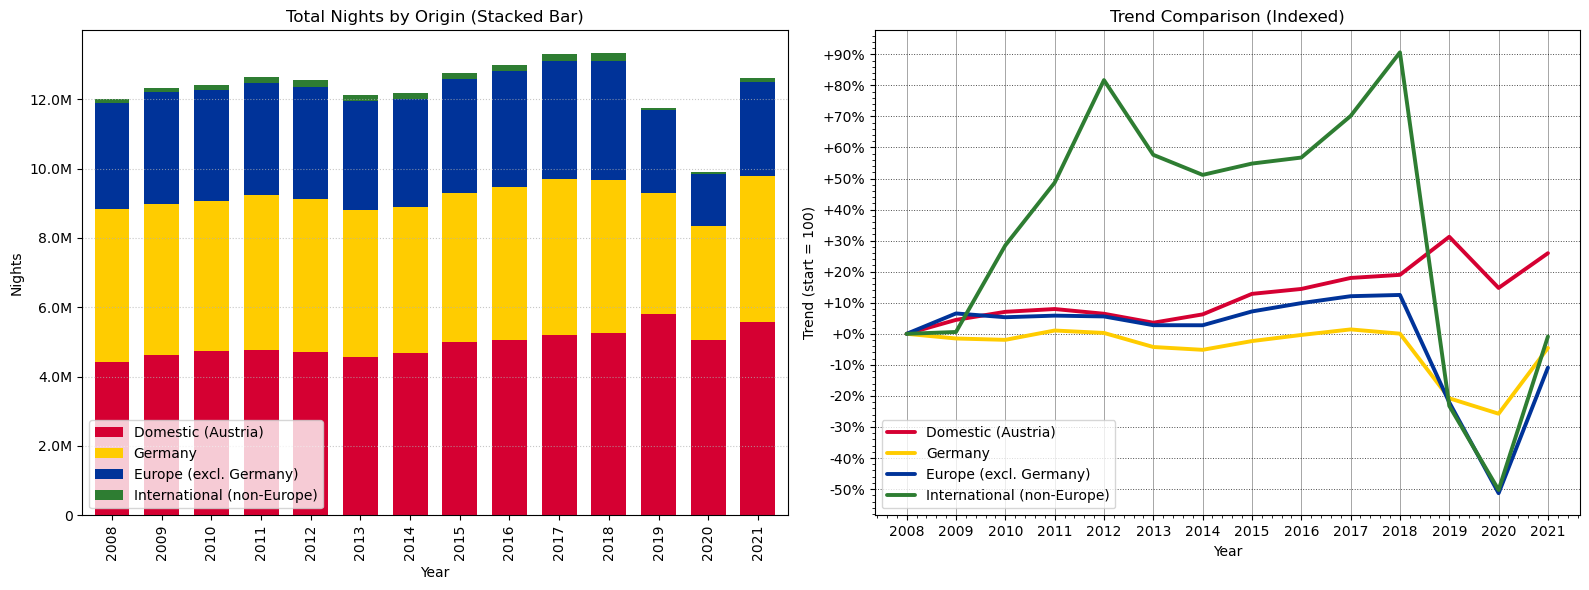

In [6]:
group_b = df_tourism.groupby(['Tourismusjahr','Herkunft Kategorie']).agg({'Übernachtungen':'sum'}).reset_index()
pivot = group_b.pivot(index='Tourismusjahr', columns='Herkunft Kategorie', values='Übernachtungen').fillna(0)

# Map columns (origin categories)
pivot.columns = [cat_map.get(col, col) for col in pivot.columns]
categories = pivot.columns

years = pivot.index
values = [pivot[cat] for cat in categories]

fig, axs = plt.subplots(1,2,figsize=(16,6))

#Stacked bar chart with mapped labels

pivot.plot(kind='bar',
           stacked=True,
           ax=axs[0],
           legend=False,
           width=0.7,
           cmap=cmap,
           )

axs[0].set_xlabel('Year')
axs[0].set_ylabel('Nights')
axs[0].set_title('Total Nights by Origin (Stacked Bar)')
axs[0].get_yaxis().set_major_formatter(FuncFormatter(human_format))
axs[0].grid(axis='y', linestyle=':', alpha=0.7)
axs[0].legend(categories, loc='lower left')


i = 0
for cat in categories:
    cat_code = {v: k for k, v in cat_map.items()}.get(cat, cat)
    data = group_b[group_b['Herkunft Kategorie'] == cat_code].sort_values('Tourismusjahr')
    indexed = data['Übernachtungen'] / data['Übernachtungen'].iloc[0] * 100
    axs[1].plot(data['Tourismusjahr'], indexed, label=cat, color = color_map[cat])



# Thicken all lines drawn on axs[1]
for ln in axs[1].lines:
    ln.set_linewidth(2.8)
    ln.set_solid_capstyle('round')

# % delta formatter (100 -> 0%, 120 -> +20%)
def rel_fmt(y, _): return f"{(y/100 - 1)*100:+.0f}%"
axs[1].yaxis.set_major_formatter(FuncFormatter(rel_fmt))

# Grid + tick spacing
axs[1].xaxis.set_major_locator(MultipleLocator(1))    # yearly
axs[1].yaxis.set_major_locator(MultipleLocator(10))   # 10 index pts = 10%
axs[1].minorticks_on()
axs[1].grid(which='major', color='black', linestyle='-', linewidth=0.7, alpha=0.35)
axs[1].set_axisbelow(True)

axs[1].set_xlabel('Year')
axs[1].set_ylabel('Trend (start = 100)')
axs[1].set_title('Trend Comparison (Indexed)')
axs[1].grid(axis='y', linestyle=':', alpha=0.7)
axs[1].legend()

plt.tight_layout()
plt.show()


## 4. Accommodation Types and Tourist Origins

Show how many nights are spent in accommodations of different types. How does the
choice of accommodation depend on origin? (2 charts)

**Deliverables:**
- Bar chart: Nights per accommodation type.
- Grouped bar chart or heatmap: Origin vs. accommodation.

**Ask:**
- Do international tourists prefer hotels over private rentals?
- Are some types only popular among locals?

# Add a new totals column
# try vertical bar chart


NameError: name 'human_format' is not defined

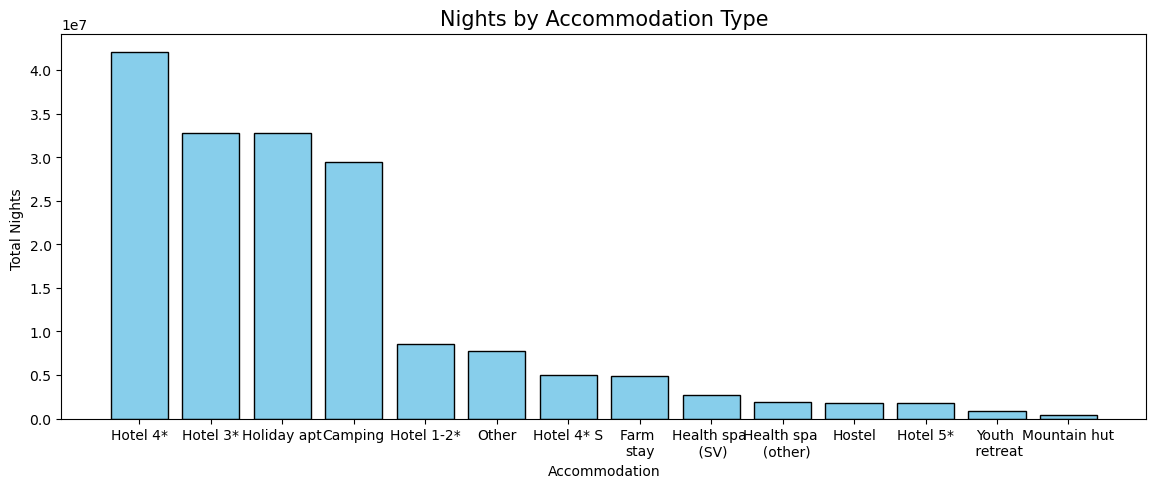

In [6]:
accom_map = {
    'Bewirtschaftete Schutzhütten': 'Mountain hut',
    'Campingplatz': 'Camping',
    'Ferienwohnung': 'Holiday apt',
    'Hotel 1 oder 2*': 'Hotel 1-2*',
    'Hotel 3*': 'Hotel 3*',
    'Hotel 4*': 'Hotel 4*',
    'Hotel 4* Superior': 'Hotel 4* S',
    'Hotel 5*': 'Hotel 5*',
    'Jugendherbergen u. -gästehäuser': 'Hostel',
    'Kinder- u. Jugenderholungsheime': 'Youth \n retreat',
    'Kurheim der Sozialversich.träger': 'Health spa \n (SV)',
    'Private u. öffentl. Kurheime': 'Health spa \n  (other)',
    'Sonstige Unterkunft': 'Other',
    'Unterkunft auf Bauernhof': 'Farm \nstay'
}


group_c = df_tourism.groupby(['Unterkunft']).agg({'Übernachtungen':'sum'})
group_c = group_c.reset_index()
group_c['Short'] = group_c['Unterkunft'].map(accom_map).fillna(group_c['Unterkunft'])
group_c =group_c.sort_values(by='Übernachtungen', ascending=False)
plt.figure(figsize=(14,5))
bars = plt.bar(group_c['Short'], group_c['Übernachtungen'], color='skyblue', edgecolor='black')
plt.title("Nights by Accommodation Type", fontsize=15)
plt.xlabel("Accommodation")
plt.ylabel("Total Nights ")
plt.gca().yaxis.set_major_formatter(FuncFormatter(human_format))
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.xticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()




group_b = df_tourism.groupby(['Unterkunft','Herkunft Kategorie']).agg({'Übernachtungen':'sum'})
group_b = group_b.reset_index()

pivot_b = group_b.pivot(index='Unterkunft', columns='Herkunft Kategorie', values='Übernachtungen').fillna(0)



pivot_raw = group_b.pivot(index='Unterkunft', columns='Herkunft Kategorie', values='Übernachtungen').fillna(0)
pivot_raw.columns = [cat_map.get(x, x) for x in pivot_raw.columns]
pivot_raw.index   = [accom_map.get(x, x) for x in pivot_raw.index]

pct = pivot_raw.div(pivot_raw.sum(axis=0), axis=1) * 100                    # column-normalized
pct['Total (%)'] = pivot_raw.sum(axis=1) / pivot_raw.values.sum() * 100     # global share
pivot_sorted = pct.sort_values('Total (%)', ascending=False)

plt.figure(figsize=(12,6))
ax = sns.heatmap(pivot_sorted, cmap='Blues', annot=True, fmt='.1f',
                 cbar_kws={'label': '%'})
ax.set_title('Accommodation Choice by Origin', fontsize=16, pad=16)
ax.set_xlabel('Origin / Total'); ax.set_ylabel('Accommodation Type')
ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()


for t in ax.get_xticklabels():
    t.set_color(color_map.get(t.get_text(), '#000000'))

# Highlight the max % in each column
for row_idx, row_name in enumerate(pivot_sorted.index):
    col_name_idmax = pivot_sorted.iloc[row_idx].idxmax()
    col_idx = list(pivot_sorted.columns).index(col_name_idmax)
    rect = patches.Rectangle(
        (col_idx, row_idx), 1, 1,
        linewidth=1.5, edgecolor='black', facecolor='none'
    )
    ax.add_patch(rect)


plt.tight_layout()
plt.show()

---

## 5. Estimated Stay Duration by Accommodation Type

The dataset is highly aggregated and only provides total arrivals (Ankünfte) and total spent
nights (Übernachtungen) in each category (year, accommodation, origin). Still, taking the
row-wise quotient of Übernachtungen by Ankünfte gives a rough estimate of the approx-
imate duration of stays. Show how this duration depends on the type of accommodation.
(1 chart)

**Formula:**
Estimated duration = `Übernachtungen / Ankünfte`

**Deliverable:**
- Box plot or bar chart: Average duration vs. accommodation type.

**Challenge:**
- Does duration vary significantly by accommodation?
- Which accommodations encourage longer stays?

---



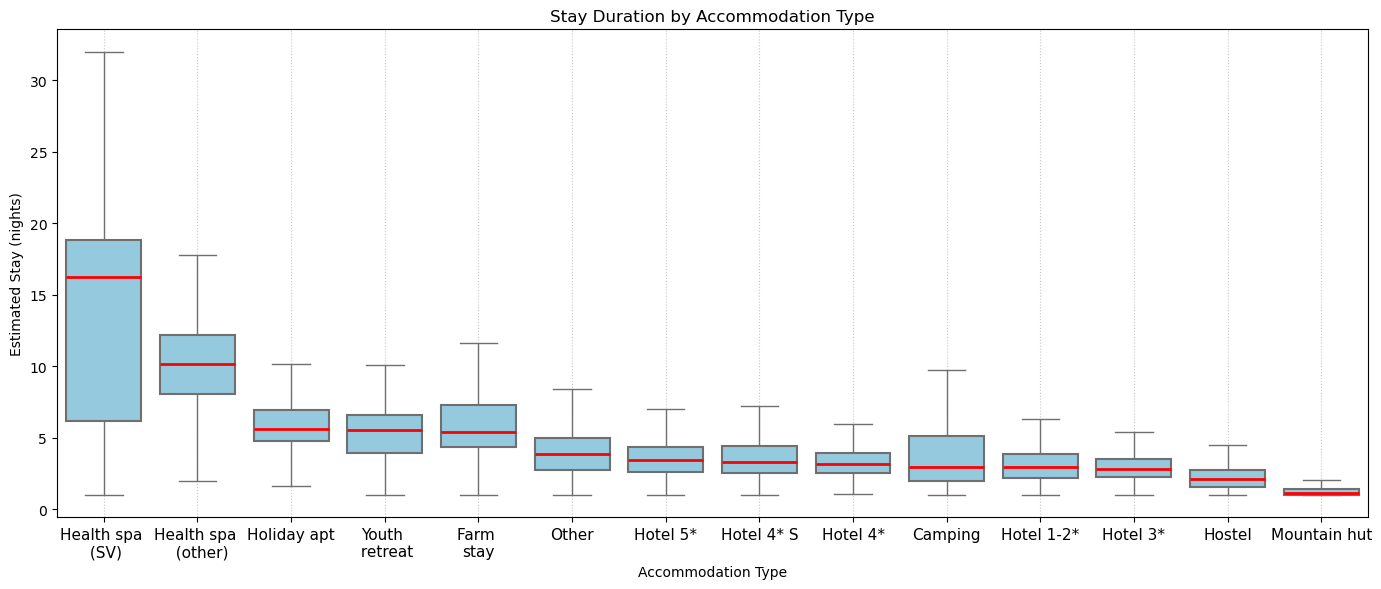

In [7]:

df_tourism['Dauer'] = df_tourism['Übernachtungen'] / df_tourism['Ankünfte']
df_tourism['Short'] = df_tourism['Unterkunft'].map(accom_map)

medians = df_tourism.groupby('Short')['Dauer'].median().sort_values(ascending=False)
ordered_accoms = medians.index.tolist()

plt.figure(figsize=(14,6))
sns.boxplot(
    y='Dauer',
    x='Short',
    data=df_tourism,
    order=ordered_accoms,
    showfliers=False,
    color='skyblue',
    boxprops=dict(linewidth=1.5),
    medianprops=dict(color='red', linewidth=2)
)
plt.ylabel('Estimated Stay (nights)')
plt.xlabel('Accommodation Type')
plt.title('Stay Duration by Accommodation Type')
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.xticks( fontsize=11)

plt.tight_layout()
plt.show()


# Importing Data

In [8]:
data = np.load('data/data_molecule/molecule.npz')
positions = data['positions']
angles = data['angles']
distances = data['distances']
atomTypes = data['atomTypes']
edges = data['edges']

# Visualizing Molecule

In [9]:
atom_color_dict = {'C': 'black', 'O': 'blue', 'N': 'red'}
atom_name_dict  = {'C': 'Carbon', 'O': 'Oxygen', 'N': 'Nitrogen'}
atom_indices = {
    c: atomTypes == c
    for c in "CON"
}

def plot_molecule(ax, molecule, kind="grey"):
    ax.view_init(45, -45)
    molecule_scatters = []
    for c in "CON":
        molecule_scatters.append(ax.scatter(
            molecule[atom_indices[c], 0], 
            molecule[atom_indices[c], 1], 
            molecule[atom_indices[c], 2], 
            marker='o', 
            linewidths=5 if kind == "grey" else 2, 
            c=atom_color_dict[c] if kind == "grey" else "black", 
            label=atom_name_dict[c] if kind == "grey" else None,
            depthshade=False
        ))
    if kind == "grey":
        ax.legend()
    
    edge_midpoints = [(molecule[ai, 1] + molecule[bi, 1]) / 2 for ai, bi in edges]   
    emin = min(edge_midpoints)
    emax = max(edge_midpoints)
    normalize_edge_midpoint = lambda ep: ((emax-ep) / (emax-emin)) * 0.5 + 0.3
    bond_alphas = [normalize_edge_midpoint(m) for m in edge_midpoints]

    
    bond_line_collections = []
    for (ai, bi), alpha in zip(edges, bond_alphas):
        match kind:
            case "color":
                bond_line_collections.append(
                    ax.plot(
                        [molecule[ai, 0], molecule[bi, 0]], 
                        [molecule[ai, 1], molecule[bi, 1]], 
                        [molecule[ai, 2], molecule[bi, 2]],
                        linewidth=4,
                    )
                )
            case "grey":
                bond_line_collections.append(
                    ax.plot(
                        [molecule[ai, 0], molecule[bi, 0]], 
                        [molecule[ai, 1], molecule[bi, 1]], 
                        [molecule[ai, 2], molecule[bi, 2]],
                        linewidth=4,
                        color="black",
                        alpha=alpha
                    )
                )
                
    return molecule_scatters, bond_line_collections

In [10]:
%matplotlib widget

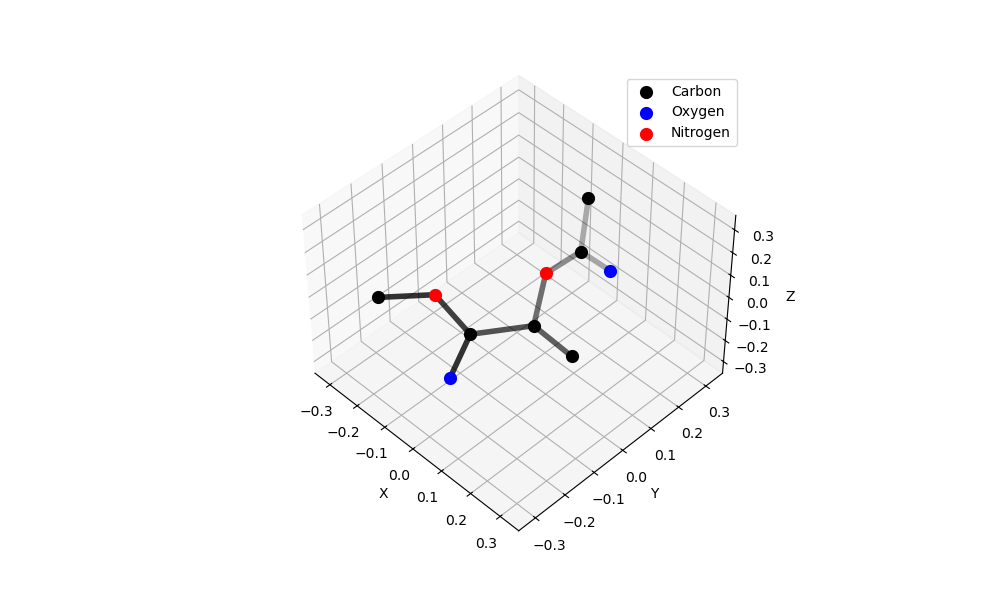

In [11]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

plot_molecule(ax, positions[0, :, :])

pos100 = positions[:100,:,:]
ax.set_xlim(np.min(pos100), np.max(pos100))
ax.set_ylim(np.min(pos100), np.max(pos100))
ax.set_zlim(np.min(pos100), np.max(pos100))

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()

In [12]:
%matplotlib inline
plt.clf()

# Animating Molecule

In [13]:
%matplotlib widget

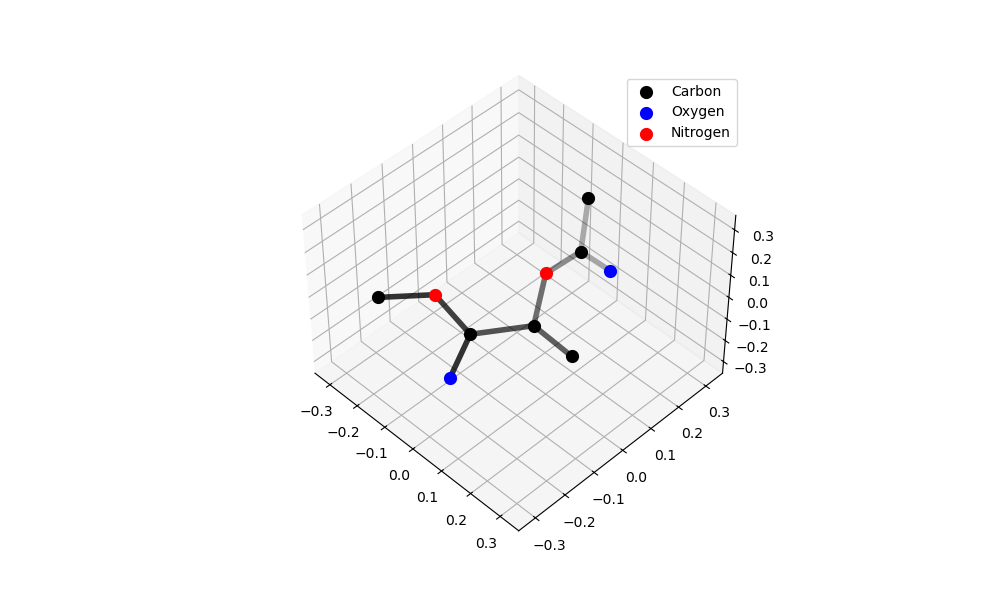

In [14]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

molecule = positions[0, :, :]
atoms, bonds = plot_molecule(ax, molecule, kind="grey")
bonds = [group[0] for group in bonds]

ax.set_xlim(np.min(pos100), np.max(pos100))
ax.set_ylim(np.min(pos100), np.max(pos100))
ax.set_zlim(np.min(pos100), np.max(pos100))

def update(frame):
    ax.set_title(f"Molecule at t={frame} (timedelta 1 picosecond)")
    mol = positions[frame, :, :]
    for scat, idx in zip(atoms, atom_indices.values()):
        scat._offsets3d = (mol[idx, 0], mol[idx, 1], mol[idx, 2])

    edge_midpoints = [(molecule[ai, 1] + molecule[bi, 1]) / 2 for ai, bi in edges]   
    emin = min(edge_midpoints)
    emax = max(edge_midpoints)
    normalize_edge_midpoint = lambda ep: ((emax-ep) / (emax-emin)) * 0.7 + 0.3
    bond_alphas = [normalize_edge_midpoint(m) for m in edge_midpoints]

    for i, ((ai, bi), line) in enumerate(zip(edges, bonds)):
        line.set_data([mol[ai, 0], mol[bi, 0]], [mol[ai, 1], mol[bi, 1]])
        line.set_3d_properties([mol[ai, 2], mol[bi, 2]])
        line.set_alpha(bond_alphas[i])

    return [atoms] + bonds

ani = animation.FuncAnimation(fig, update, frames=100, interval=300, blit=False)

start_button = Button(description="Start", button_style='success')
stop_button = Button(description="Stop", button_style='danger')

def start_animation(b):
    ani.event_source.start()

def stop_animation(b):
    ani.event_source.stop()

start_button.on_click(start_animation)
stop_button.on_click(stop_animation)

display(HBox([start_button, stop_button]))

In [15]:
%matplotlib inline
ani.pause()

# Angle Histogram

In [16]:
phi = angles[:, 1]
psi = angles[:, 0]

def create_angles_hist(ax, phi, psi, alpha_phi=1.0, alpha_psi=1.0):
    hist1 = ax.hist(phi, bins=90, range=(-np.pi, np.pi), density=True, color="red", alpha=alpha_phi, label="$\phi$")
    hist2 = ax.hist(psi, bins=90, range=(-np.pi, np.pi), density=True, color="black", alpha=alpha_psi, label="$\psi$")
    
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)    
    ax.grid(True)
    
    theta = np.linspace(0, 2*np.pi, 9)
    labels_degrees = [f'{int(np.degrees(t))}' for t in theta]
    labels = [
        r"$0$",
        r"$\frac{\pi}{4}$",
        r"$\frac{\pi}{2}$",
        r"$\frac{3\pi}{4}$",
        r"-$\pi$ \ $\pi$",
        r"$-\frac{3\pi}{4}$",
        r"$-\frac{\pi}{2}$",
        r"$-\frac{\pi}{4}$",
        ""
    ]
    
    ax.set_xticks(theta)
    ax.set_xticklabels(labels)
    ax.legend(bbox_to_anchor=(1.33,0.2), frameon=False)
    return fig, ax

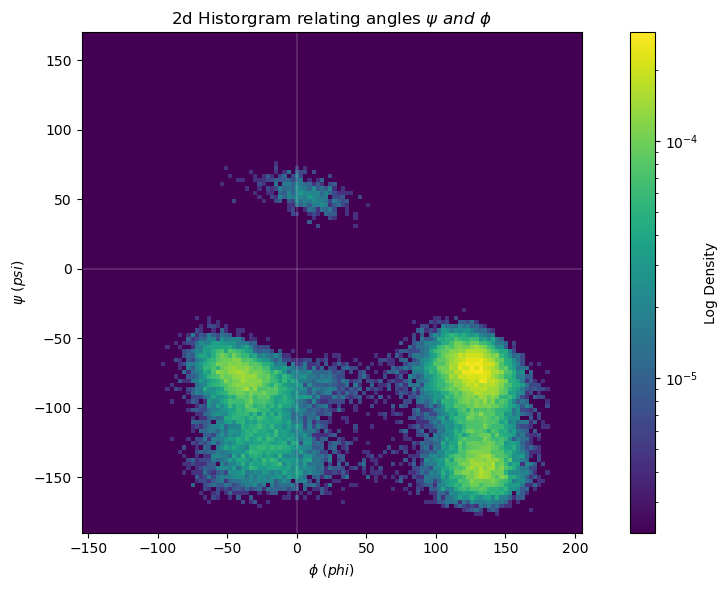

In [18]:
# Plot contours
phi_deg = np.degrees(phi)
psi_deg = np.degrees(psi)
phi_shift = 25
psi_shift = -10
phi_shifted = (phi_deg - phi_shift + 180) % 360 - 180
psi_shifted = (psi_deg - psi_shift + 180) % 360 - 180

plt.figure(figsize=(10, 6))
H, xedges, yedges = np.histogram2d(
    phi_shifted, 
    psi_deg, 
    bins=120,
    range=[[-180 + phi_shift, 180 + phi_shift], [-180 + psi_shift, 180 + psi_shift]], 
    density=True,
)

H[H == 0] = H[H != 0].min()

plt.imshow(H.T, origin='lower',
           extent=[-180 + phi_shift, 180 + phi_shift, -180 + psi_shift, 180 + psi_shift],
           cmap='viridis', norm="log"
)

cbar = plt.colorbar(label='Log Density')
plt.xlabel("$\phi \ (phi)$")
plt.ylabel("$\psi \ (psi)$")
plt.title("2d Historgram relating angles $\psi \ and\  \phi$")

plt.xlim([-180 + phi_shift, 180 + phi_shift])
plt.ylim([-180 + psi_shift, 180 + psi_shift])
plt.plot([0, 0], [-180 + psi_shift, 180 + psi_shift], c='white', linewidth=0.2)
plt.plot([-180 + phi_shift, 180 + phi_shift], [0, 0], c='white', linewidth=0.2)
plt.tight_layout()
ticks = cbar.get_ticks()
plt.show()

# Angle Animation

In [19]:
%matplotlib widget

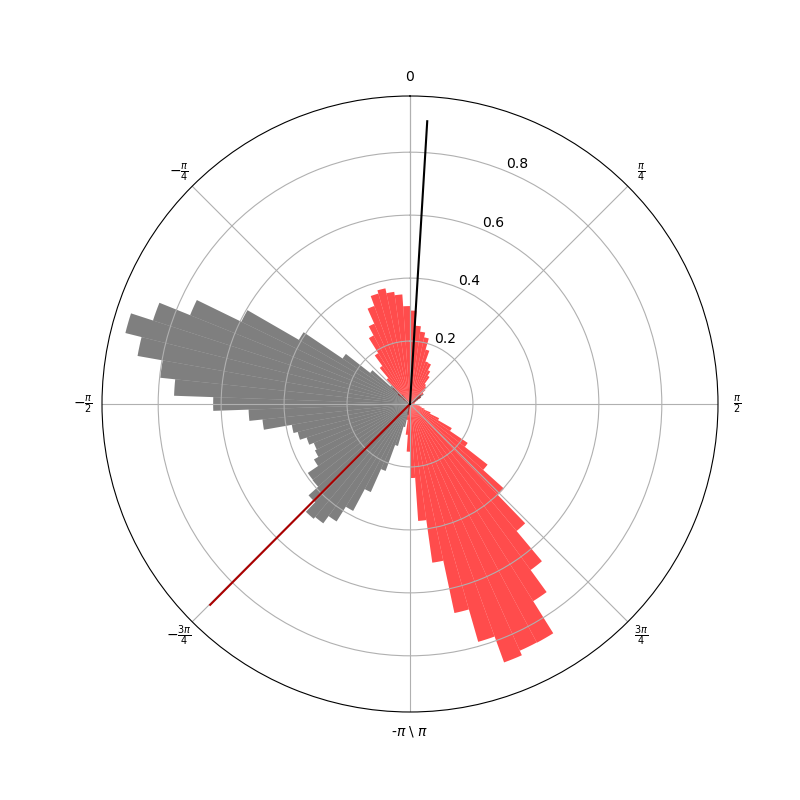

In [20]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='polar')

create_angles_hist(ax, phi, psi, alpha_phi=0.7, alpha_psi=0.5)

def init(ax):
    phi_angle, psi_angle = angles[0]
    line_phi, = ax.plot([0, phi_angle], [0, 0.9], color="#AA0000")
    line_psi, = ax.plot([0, psi_angle], [0, 0.9], color="black")
    return line_phi, line_psi

def update(i):
    phi_angle, psi_angle = phi[i], psi[i]

    line_phi.set_data([0, phi_angle], [0, 0.9])
    line_psi.set_data([0, psi_angle], [0, 0.9])

    ax.set_title(f"Time Step {i}")

    return line_phi, line_psi

line_phi, line_psi = init(ax)

ani = animation.FuncAnimation(fig, update, frames=100, blit=True, repeat=True)

start_button = Button(description="Start", button_style='success')
stop_button = Button(description="Stop", button_style='danger')

def start_animation(b):
    ani.event_source.start()

def stop_animation(b):
    ani.event_source.stop()

start_button.on_click(start_animation)
stop_button.on_click(stop_animation)

display(HBox([start_button, stop_button]))

In [21]:
plt.clf()
ani.pause()

# PCA of Distances

In [22]:
%matplotlib inline

In [23]:
X = distances
n_samples = X.shape[0]
X_centered = X - np.mean(X, axis=0)
pca = PCA()
X_transformed = pca.fit_transform(X_centered)

# We center the data and compute the sample covariance matrix.
cov_matrix = np.dot(X_centered.T, X_centered) / n_samples
spectrum = [
    np.dot(eigenvector.T, np.dot(cov_matrix, eigenvector))
    for eigenvector in pca.components_
]

cumsum = np.cumsum([0] + spectrum)
cumsum /= cumsum[-1]

<Figure size 888.889x888.889 with 0 Axes>

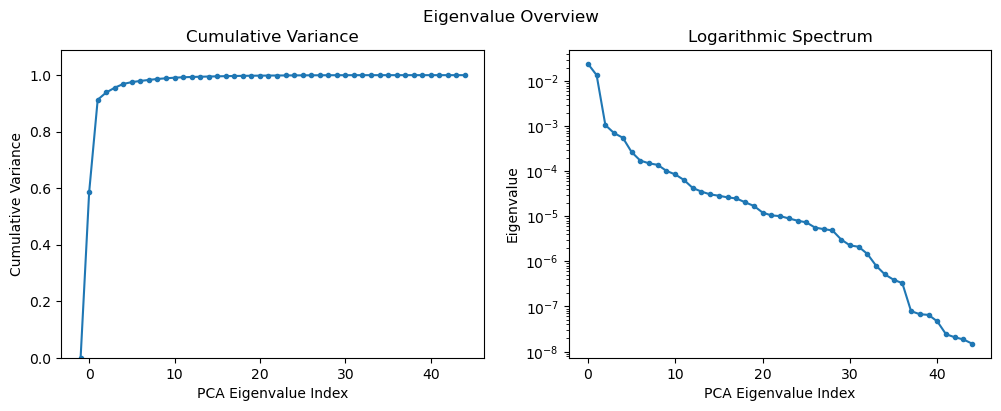

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
ax = axs[0]
ax.plot(np.arange(-1, len(cumsum) - 1), cumsum, marker='.')
ax.set_ylim(0, 1.09)
ax.set_xlabel("PCA Eigenvalue Index")
ax.set_ylabel("Cumulative Variance")
ax.set_title("Cumulative Variance")

ax = axs[1]
ax.plot(np.arange(len(spectrum)), spectrum, marker='.')
ax.set_yscale("log")
ax.set_xlabel("PCA Eigenvalue Index")
ax.set_ylabel("Eigenvalue")
ax.set_title("Logarithmic Spectrum")

fig.suptitle('Eigenvalue Overview');

In [25]:
n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=0)
phi_psi_cluster_labels = kmeans.fit_predict(angles)

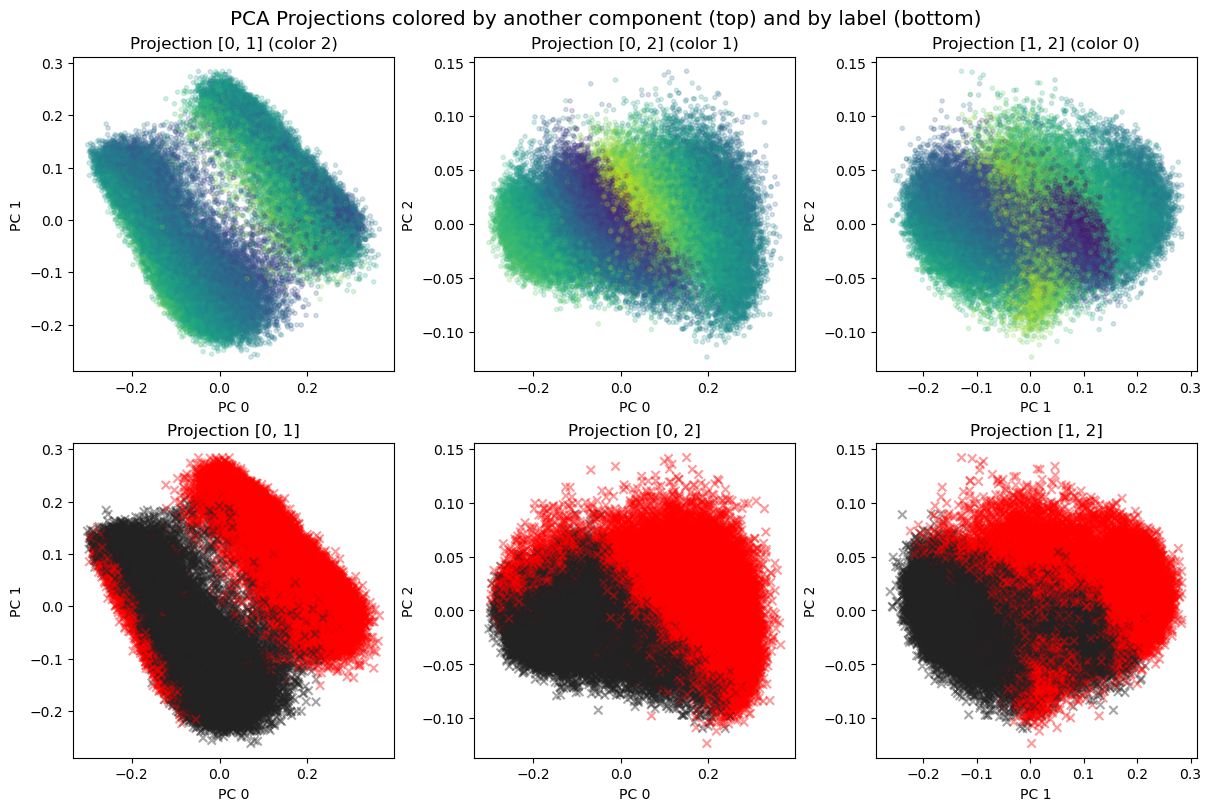

In [26]:
fig, axs = plt.subplots(2, 3, figsize=(12, 8), constrained_layout=True)

two_color_cmap = ListedColormap(["#222222", "red"])

for ax, (i, j, k) in zip(axs[0], [(0,1, 2), (0,2, 1), (1,2, 0)]):
    ax.scatter(X_transformed[:, i], X_transformed[:, j], c=X_transformed[:, k], marker='.', alpha=0.2, cmap=cm.viridis)
    ax.set_xlabel(f'PC {i}')
    ax.set_ylabel(f'PC {j}')
    ax.set_title(f'Projection [{i}, {j}] (color {k})')

for ax, (i, j, k) in zip(axs[1], [(0,1, 2), (0,2, 1), (1,2, 0)]):
    ax.scatter(X_transformed[:, i], X_transformed[:, j], c=phi_psi_cluster_labels, cmap=two_color_cmap, marker='x', alpha=0.4);
    ax.set_xlabel(f'PC {i}')
    ax.set_ylabel(f'PC {j}')
    ax.set_title(f'Projection [{i}, {j}]')
    
fig.suptitle("PCA Projections colored by another component (top) and by label (bottom)", size="x-large");
plt.show()

comparing the result of the PCA and the distribution of the anles below. the features look very similar.

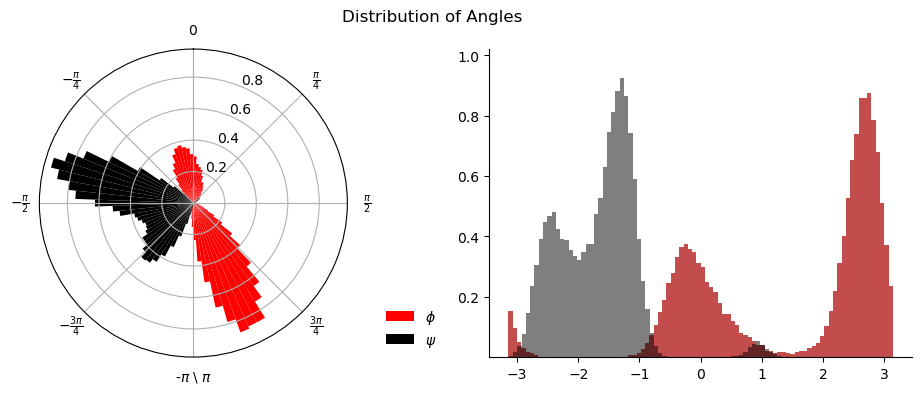

In [12]:
fig = plt.figure(figsize=(12, 4))

ax0 = fig.add_subplot(1, 2, 1, projection='polar')
ax1 = fig.add_subplot(1, 2, 2)

create_angles_hist(ax0, phi, psi)

ax1.hist(phi, bins=90, alpha=0.7, color="#AA0000", density=True)
ax1.hist(psi, bins=90, alpha=0.5, color="black", density=True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_ylim(0.001,1.02)


fig.suptitle("Distribution of Angles");

In [13]:
%matplotlib widget

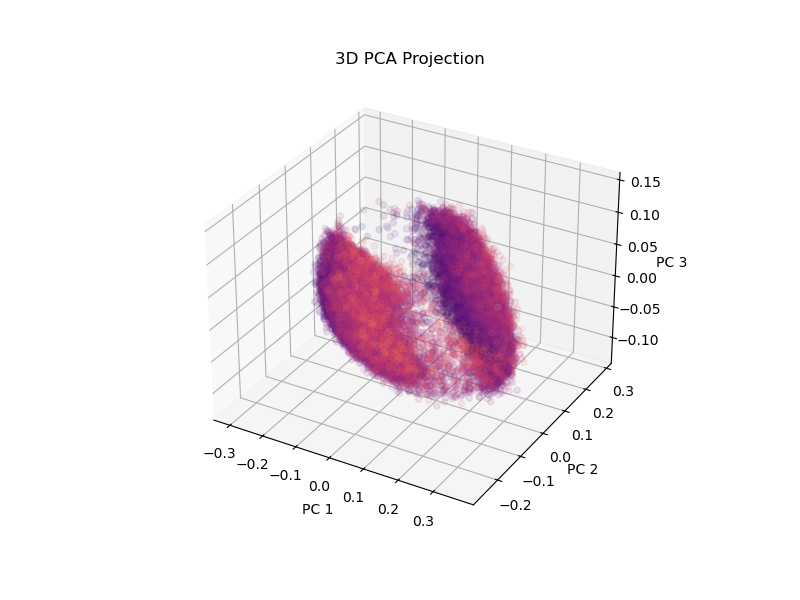

In [14]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_transformed[:, 0], X_transformed[:, 1], X_transformed[:, 2], c=X_transformed[:, 3], alpha=0.1, cmap=cm.magma)
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('3D PCA Projection')
plt.show()

# Length Distribution

In [27]:
%matplotlib inline

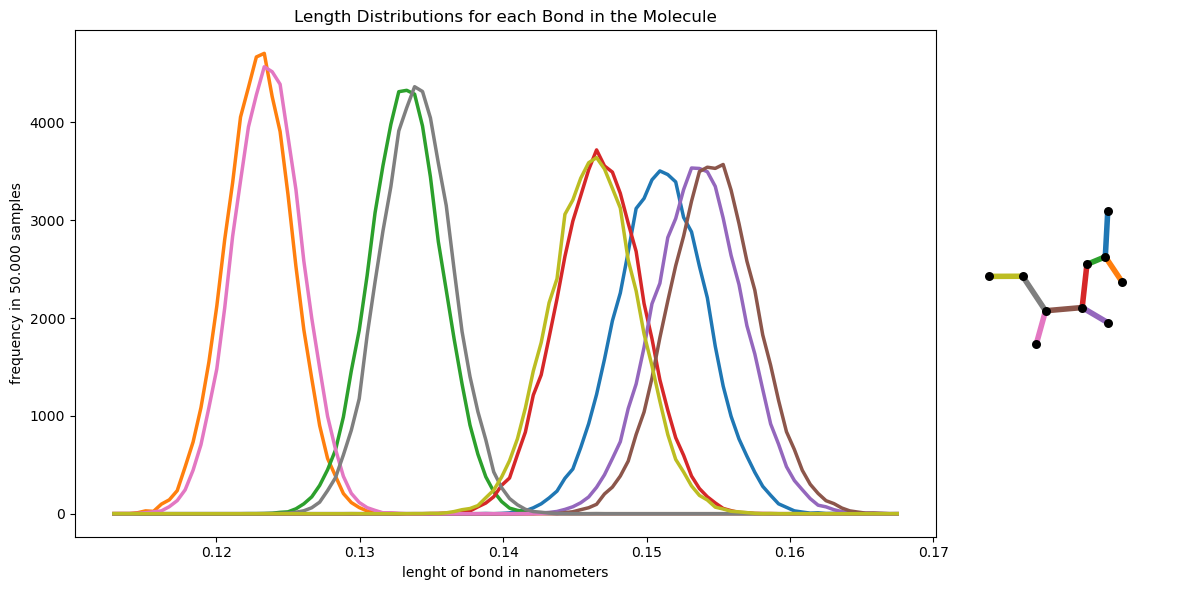

In [28]:
fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1])
ax_mol = fig.add_subplot(gs[1], projection='3d')
ax_hist = fig.add_subplot(gs[0])

molecule = positions[0, :, :]
plot_molecule(ax_mol, molecule, kind="color")
ax_mol.grid(False)
ax_mol.axis("off")

start = positions[:, edges[:, 0], :]
end = positions[:, edges[:, 1], :]
lengths = np.linalg.norm(start - end, axis=2)

num_bins = 100
all_data = lengths.ravel()
bin_edges = np.linspace(all_data.min(), all_data.max(), num_bins + 1)

for edge_idx in range(lengths.shape[1]):
    hist, _ = np.histogram(lengths[:, edge_idx], bins=bin_edges)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    ax_hist.plot(bin_centers, hist, label=f'Edge {edge_idx + 1}', linewidth=2.5)

ax_hist.set_title("Length Distributions for each Bond in the Molecule")
ax_hist.set_xlabel("lenght of bond in nanometers")
ax_hist.set_ylabel("frequency in 50.000 samples")
plt.tight_layout()
plt.show()